Data shape: (20640, 10)

First 5 rows:
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Train size: 16,512 | Test size: 4,

/var/folders/rx/657_nq8j7hn6xfx0ysfcljzc0000gn/T/ipykernel_74598/1080662552.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=ocean_proximity_original, y=y, palette='Set3')


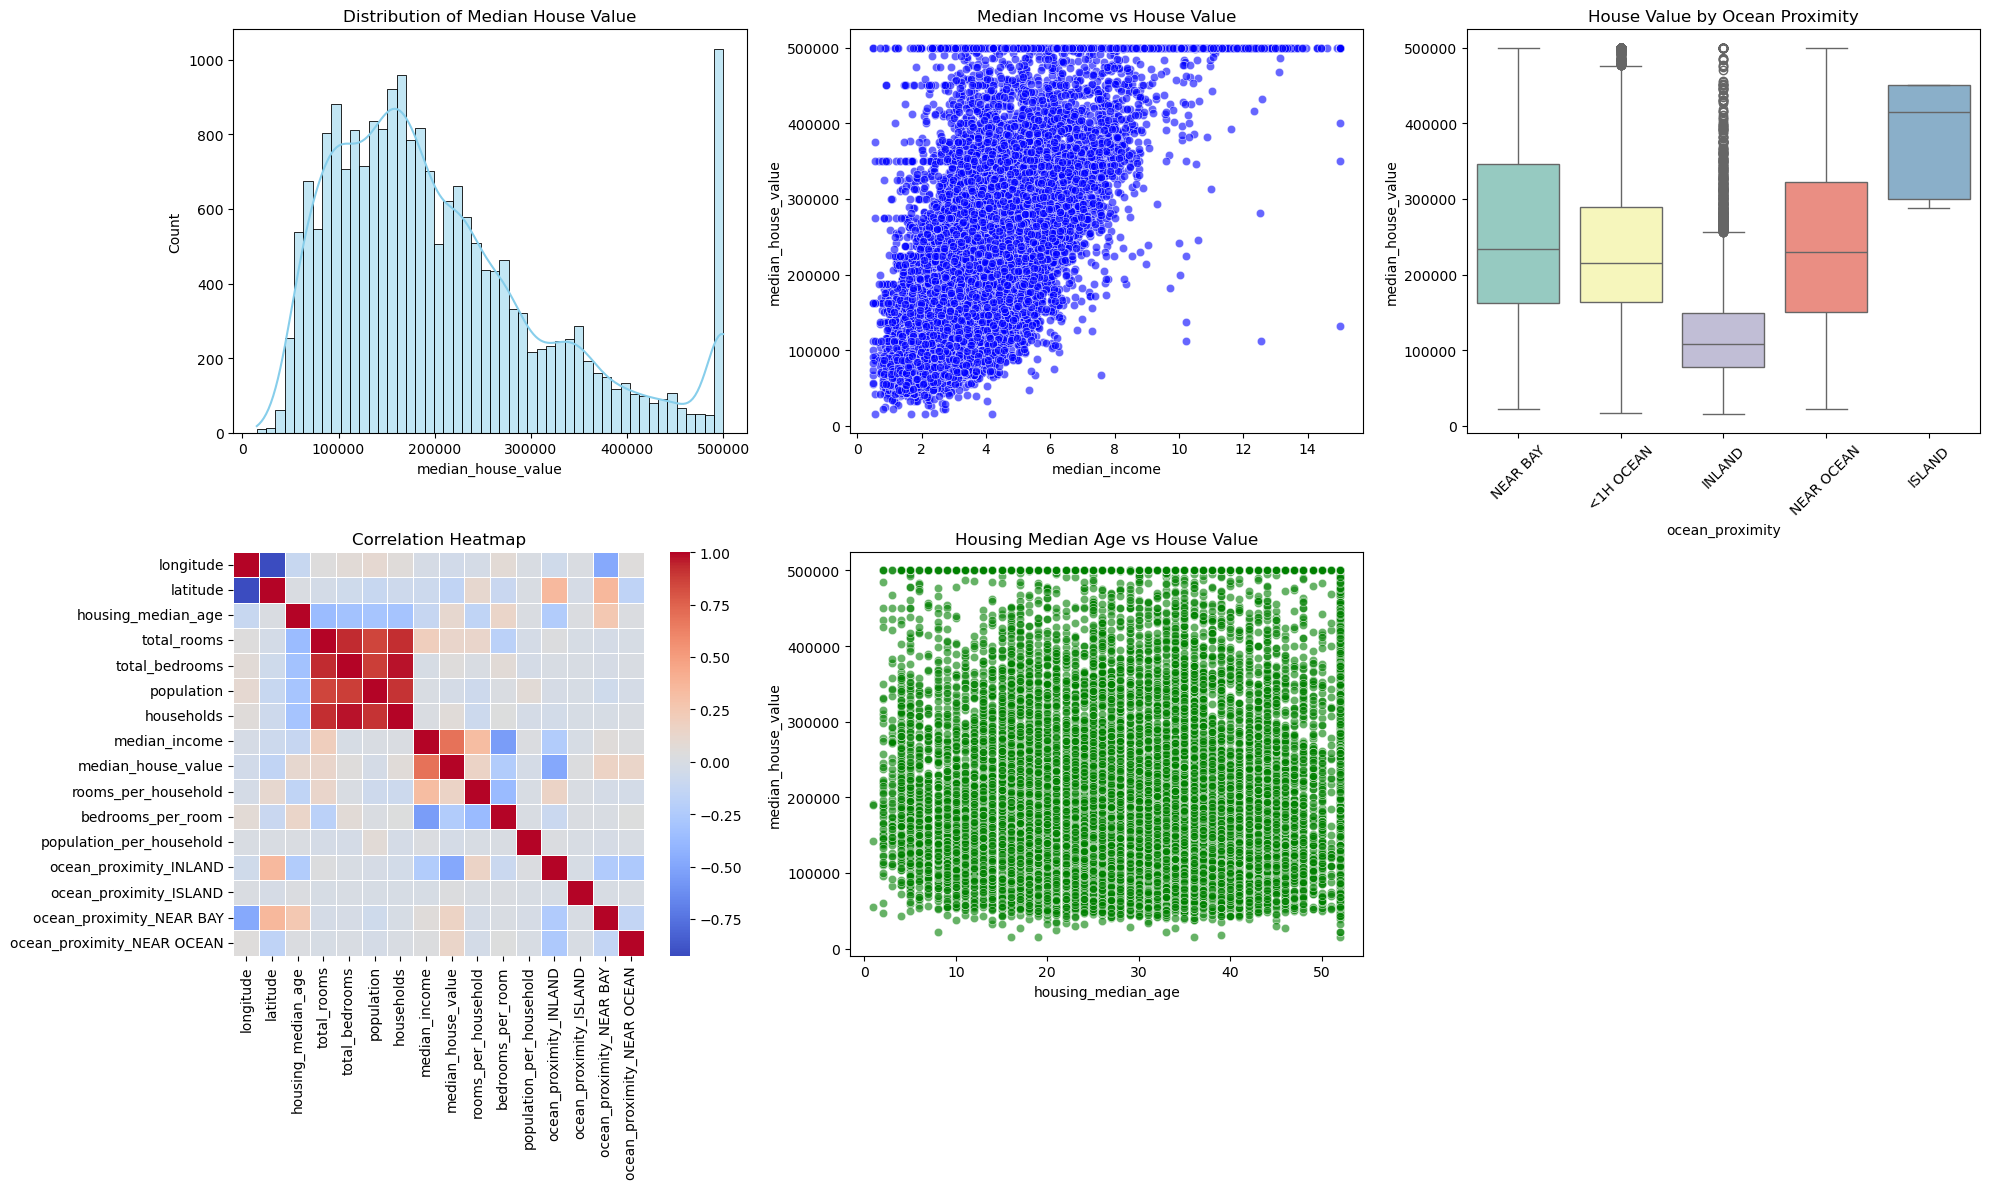

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# ====================== 1. Load Data ======================
df = pd.read_csv('housing.csv')

print("Data shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# ====================== 2. Data Preprocessing & Feature Engineering ======================
# Keep a copy of original ocean_proximity for plotting
ocean_proximity_original = df['ocean_proximity'].copy()

# Fill missing values
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# Feature Engineering
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# One-hot encoding
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

# ====================== 3. Split Data ======================
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")

# ====================== 4. EDA Plots ======================
plt.figure(figsize=(20, 12))

# 1. Distribution of Median House Value
plt.subplot(2, 3, 1)
sns.histplot(y, kde=True, bins=50, color='skyblue')
plt.title('Distribution of Median House Value')

# 2. Median Income vs House Value
plt.subplot(2, 3, 2)
sns.scatterplot(x=df['median_income'], y=y, alpha=0.6, color='blue')
plt.title('Median Income vs House Value')

# 3. House Value by Ocean Proximity (using original column)
plt.subplot(2, 3, 3)
sns.boxplot(x=ocean_proximity_original, y=y, palette='Set3')
plt.title('House Value by Ocean Proximity')
plt.xticks(rotation=45)

# 4. Correlation Heatmap
plt.subplot(2, 3, 4)
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

# 5. Housing Median Age vs House Value
plt.subplot(2, 3, 5)
sns.scatterplot(x=df['housing_median_age'], y=y, alpha=0.6, color='green')
plt.title('Housing Median Age vs House Value')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# ====================== 5. OLS Linear Regression Model ======================
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()

print("\n" + "="*70)
print("OLS Regression Model Summary")
print("="*70)
print(model.summary())

# ====================== 6. Model Evaluation on Test Set ======================
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*70)
print("Test Set Performance")
print("="*70)
print(f"RMSE : ${rmse:,.0f}")
print(f"R²   : {r2:.4f}")

# ====================== 7. Actual vs Predicted Plot ======================
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, s=8, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Values (Test Set)')
plt.legend()
plt.grid(True)
plt.savefig('actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# ====================== 8. Save Results ======================
results = pd.DataFrame({
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred.reset_index(drop=True),
    'Residual': y_test.reset_index(drop=True) - y_pred.reset_index(drop=True)
})
results.to_csv('prediction_results.csv', index=False)
print("\n✅ All done! Files saved:")
print("   - eda_plots.png")
print("   - actual_vs_predicted.png")
print("   - prediction_results.csv")